In [ ]:
"""Build manifest CSVs for v9 and v11-processing, then a combined CSV
and an overlap (by filename) report.

Per-row schema:
    filepath, filename, label, dataset

`fake/` -> label 0, `real/` -> label 1.
"""

from pathlib import Path

import pandas as pd

PROCESSED_ROOT = Path("/home/taiaburrahman/dataset_manager_pro/data/processed")
OUT_DIR = Path("/home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv")

V9_ROOT = PROCESSED_ROOT / "v9"
V11_ROOT = PROCESSED_ROOT / "v11-processing"

V9_CSV = OUT_DIR / "GAID_Dataset_v9.csv"
V11_CSV = OUT_DIR / "GAID_Dataset_v11-processing.csv"
COMBINED_CSV = OUT_DIR / "GAID_Dataset_v9_v11-processing_combined.csv"
OVERLAP_CSV = OUT_DIR / "GAID_Dataset_v9_v11-processing_overlap.csv"

LABEL_MAP = {"fake": 0, "real": 1}
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".jfif", ".gif", ".bmp", ".tiff"}
MAX_DEPTH = 3      # distribution charts: <dataset>/<real|fake>/<folder>/
OVERLAP_DEPTH = 2  # overlap key: /<folder>/<sub_folder>/ + filename


def build_manifest(root: Path, dataset_name: str) -> pd.DataFrame:
    rows = []
    for label_name, label_value in LABEL_MAP.items():
        sub_root = root / label_name
        if not sub_root.exists():
            print(f"[warn] missing split: {sub_root}")
            continue
        for f in sub_root.rglob("*"):
            if not f.is_file():
                continue
            if f.suffix.lower() not in IMAGE_EXTS:
                continue
            rows.append(
                {
                    "filepath": str(f),
                    "filename": f.name,
                    "label": label_value,
                    "dataset": dataset_name,
                }
            )
    return pd.DataFrame(rows, columns=["filepath", "filename", "label", "dataset"])


def depth_key(path_str: str, root: Path, max_depth: int = MAX_DEPTH) -> str:
    rel_parts = Path(path_str).relative_to(root.parent).parts
    return "/".join(rel_parts[:max_depth]) + "/"


def subfolder_key(path_str: str, root: Path, depth: int = OVERLAP_DEPTH) -> str:
    """Last `depth` folder steps before the filename (right-anchored).

    The dataset name (v9 / v11-processing) and the filename itself are dropped;
    we then take the rightmost `depth` folder components, i.e.
    `<folder_depth>/.../<folder_2>/<folder_1>/`. Files shallower than `depth`
    use whatever folders they have.

    Example with depth=3:
        v9/fake/ai_image_x_collection_feb25_cleaned/midjourney/foo.jpg
            -> 'fake/ai_image_x_collection_feb25_cleaned/midjourney/'
        v11-processing/fake/ai_image_website_june25/sub_a/sub_b/foo.jpg
            -> 'ai_image_website_june25/sub_a/sub_b/'
    """
    rel_parts = Path(path_str).relative_to(root).parts[:-1]  # drop filename
    return "/".join(rel_parts[-depth:]) + "/"


def distribution(df: pd.DataFrame, root: Path) -> pd.DataFrame:
    dist = (
        df.assign(folder=df["filepath"].map(lambda p: depth_key(p, root)))
          .groupby(["folder", "label"], as_index=False)
          .size()
          .rename(columns={"size": "count"})
          .sort_values(["folder", "label"])
          .reset_index(drop=True)
    )
    total = pd.DataFrame(
        [{"folder": "TOTAL", "label": "", "count": int(dist["count"].sum())}]
    )
    return pd.concat([dist, total], ignore_index=True)


def save_csv(df: pd.DataFrame, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)
    size_mb = out_path.stat().st_size / (1024 ** 2)
    print(f"Saved : {out_path}  ({len(df):,} rows, {size_mb:.2f} MB)")


pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output dir : {OUT_DIR}")

Output dir : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv


In [32]:
"""Step 1: v9 dataset manifest + distribution."""

df_v9 = build_manifest(V9_ROOT, "v9")
save_csv(df_v9, V9_CSV)

print(f"Total rows   : {len(df_v9):,}")
print(f"Label counts : {df_v9['label'].value_counts().to_dict()}")
print()

dist_v9 = distribution(df_v9, V9_ROOT)
print(f"Folders      : {dist_v9[dist_v9['folder'] != 'TOTAL']['folder'].nunique()}")
print()
dist_v9

Saved : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9.csv  (693,252 rows, 109.19 MB)
Total rows   : 693,252
Label counts : {0: 356878, 1: 336374}

Folders      : 2



,folder,label,count
0,v9/fake/,0,356878
1,v9/real/,1,336374
2,TOTAL,,693252


In [33]:
"""Step 2: v11-processing dataset manifest + distribution."""

df_v11 = build_manifest(V11_ROOT, "v11-processing")
save_csv(df_v11, V11_CSV)

print(f"Total rows   : {len(df_v11):,}")
print(f"Label counts : {df_v11['label'].value_counts().to_dict()}")
print()

dist_v11 = distribution(df_v11, V11_ROOT)
print(f"Folders      : {dist_v11[dist_v11['folder'] != 'TOTAL']['folder'].nunique()}")
print()
dist_v11

Saved : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v11-processing.csv  (796,516 rows, 207.78 MB)
Total rows   : 796,516
Label counts : {0: 654414, 1: 142102}

Folders      : 2



,folder,label,count
0,v11-processing/fake/,0,654414
1,v11-processing/real/,1,142102
2,TOTAL,,796516


In [34]:
"""Step 3: combined manifest (v9 + v11-processing)."""

df_combined = pd.concat([df_v9, df_v11], ignore_index=True)
save_csv(df_combined, COMBINED_CSV)

summary = (
    df_combined.groupby(["dataset", "label"], as_index=False)
               .size()
               .rename(columns={"size": "count"})
               .sort_values(["dataset", "label"])
               .reset_index(drop=True)
)
total = pd.DataFrame(
    [{"dataset": "TOTAL", "label": "", "count": int(summary["count"].sum())}]
)
summary_with_total = pd.concat([summary, total], ignore_index=True)

print(f"Combined rows : {len(df_combined):,}")
print(f"Datasets      : {sorted(df_combined['dataset'].unique())}")
print()
summary_with_total

Saved : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_v11-processing_combined.csv  (1,489,768 rows, 316.97 MB)
Combined rows : 1,489,768
Datasets      : ['v11-processing', 'v9']



,dataset,label,count
0,v11-processing,0,654414
1,v11-processing,1,142102
2,v9,0,356878
3,v9,1,336374
4,TOTAL,,1489768


In [35]:
"""Step 4: overlap report between v9 and v11-processing.

Match key   : (filename, subfolder)
              subfolder = last OVERLAP_DEPTH folder steps before the filename
              (right-anchored), excluding the dataset name. So a file at
              v11-processing/fake/ai_image_website_june25/sub_a/sub_b/foo.jpg
              gets subfolder 'ai_image_website_june25/sub_a/sub_b/'.
Definition  : the same filename lives under the same N-step trailing folder
              path in both datasets (with N = OVERLAP_DEPTH = 3).
"""

df_v9_keyed = df_v9.assign(
    subfolder=df_v9["filepath"].map(lambda p: subfolder_key(p, V9_ROOT))
)
df_v11_keyed = df_v11.assign(
    subfolder=df_v11["filepath"].map(lambda p: subfolder_key(p, V11_ROOT))
)
df_combined_keyed = pd.concat([df_v9_keyed, df_v11_keyed], ignore_index=True)

key_cols = ["filename", "subfolder"]

v9_keys = df_v9_keyed[key_cols].drop_duplicates()
v11_keys = df_v11_keyed[key_cols].drop_duplicates()

overlap_keys = v9_keys.merge(v11_keys, on=key_cols, how="inner")

# Attach a label to each overlap key by joining back to the source frames.
# If v9 and v11 disagree on label for the same (filename, subfolder) we keep
# both for inspection; otherwise we get a single value.
v9_labels = (df_v9_keyed[key_cols + ["label"]]
             .drop_duplicates()
             .rename(columns={"label": "label_v9"}))
v11_labels = (df_v11_keyed[key_cols + ["label"]]
              .drop_duplicates()
              .rename(columns={"label": "label_v11"}))
overlap_keys = (overlap_keys
                .merge(v9_labels, on=key_cols, how="left")
                .merge(v11_labels, on=key_cols, how="left"))
overlap_keys["label"] = overlap_keys["label_v9"]
label_mismatch = overlap_keys["label_v9"] != overlap_keys["label_v11"]
if label_mismatch.any():
    print(f"[warn] {int(label_mismatch.sum()):,} overlap keys have different "
          f"labels in v9 vs v11 (using v9's label).")

overlap = (
    df_combined_keyed.merge(overlap_keys[key_cols], on=key_cols, how="inner")
                     .sort_values(key_cols + ["dataset"])
                     .reset_index(drop=True)
)
save_csv(overlap, OVERLAP_CSV)

print(f"v9 unique (filename,subfolder)     : {len(v9_keys):,}")
print(f"v11 unique (filename,subfolder)    : {len(v11_keys):,}")
print(f"Overlap unique (filename,subfolder): {len(overlap_keys):,}")
print(f"Overlap rows in combined CSV       : {len(overlap):,}")
print()

if not overlap_keys.empty:
    overlap_by_subfolder = (
        overlap_keys.groupby("subfolder", as_index=False)
                    .size()
                    .rename(columns={"size": "overlap_files"})
                    .sort_values("overlap_files", ascending=False)
                    .reset_index(drop=True)
    )
    print(f"Overlap subfolders : {len(overlap_by_subfolder):,} (showing top 30)")
    print(overlap_by_subfolder.head(30).to_string(index=False))
    print()

    overlap_by_label = (
        overlap_keys.assign(label_name=overlap_keys["label"].map(LABEL_NAME))
                    .groupby("label_name", as_index=False)
                    .size()
                    .rename(columns={"size": "unique_files"})
    )
    print("Overlap by label:")
    print(overlap_by_label.to_string(index=False))
else:
    print("No overlap between v9 and v11-processing on (filename, subfolder).")

Saved : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_v11-processing_overlap.csv  (5,895 rows, 0.83 MB)
v9 unique (filename,subfolder)     : 691,851
v11 unique (filename,subfolder)    : 728,439
Overlap unique (filename,subfolder): 2,844
Overlap rows in combined CSV       : 5,895

Overlap subfolders : 1 (showing top 30)
       subfolder  overlap_files
real/PubDB_Real/           2844

Overlap by label:
label_name  unique_files
      real          2844


In [36]:
"""Step 5: visual report.

Generates a multi-panel figure plus per-dataset folder charts and an
overlap chart, saving each as a PNG next to the CSVs.
"""

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

REPORT_DIR = OUT_DIR / "reports_v9_v11"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_NAME = {0: "fake", 1: "real"}
DS_PALETTE = {"v9": "#4C72B0", "v11-processing": "#DD8452"}
LABEL_PALETTE = {"fake": "#C44E52", "real": "#55A868"}


def annotate_bars(ax, fmt="{:,.0f}", padding=3):
    for c in ax.containers:
        ax.bar_label(c, fmt=fmt, padding=padding, fontsize=10)


def short_folder(name: str) -> str:
    """Drop the dataset prefix to keep tick labels readable."""
    parts = name.rstrip("/").split("/")
    return "/".join(parts[1:]) if len(parts) > 1 else name

Saved : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/reports_v9_v11/summary.png


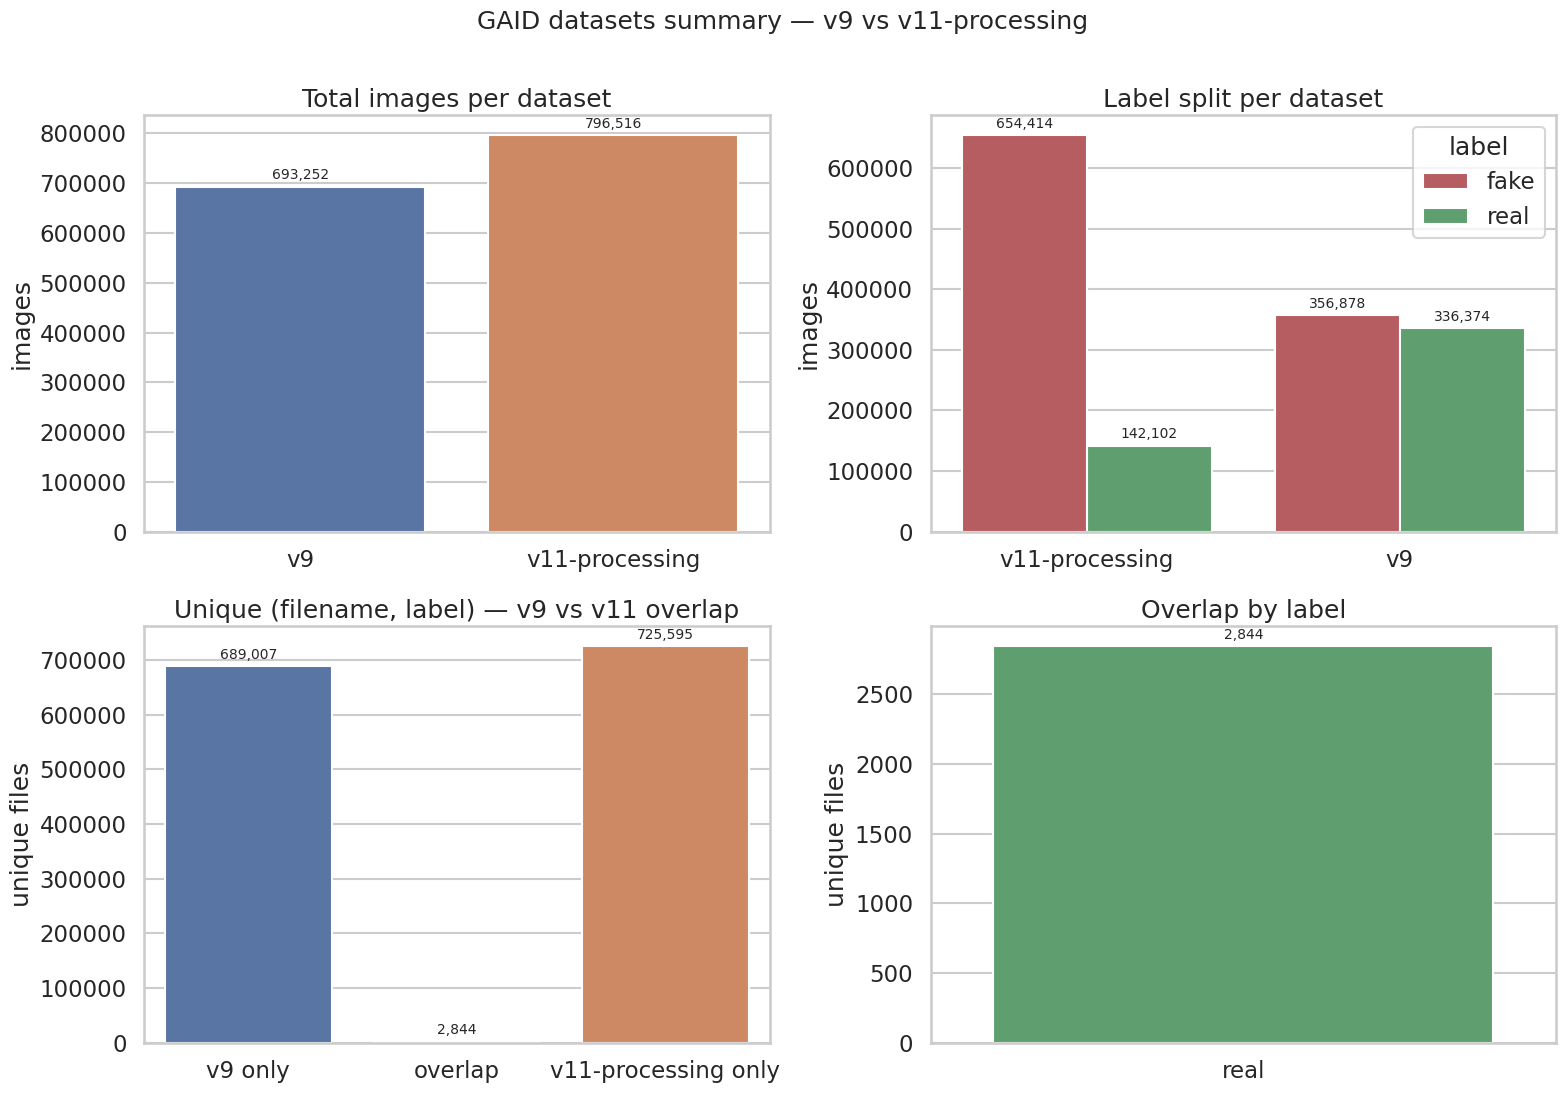

In [37]:
"""Top-level summary figure: totals, label splits, overlap."""

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("GAID datasets summary — v9 vs v11-processing", fontsize=18, y=1.00)

ax = axes[0, 0]
totals = pd.DataFrame(
    {"dataset": ["v9", "v11-processing"], "count": [len(df_v9), len(df_v11)]}
)
sns.barplot(
    data=totals, x="dataset", y="count",
    hue="dataset", palette=DS_PALETTE, legend=False, ax=ax,
)
ax.set_title("Total images per dataset")
ax.set_xlabel("")
ax.set_ylabel("images")
annotate_bars(ax)

ax = axes[0, 1]
label_split = (
    df_combined.assign(label_name=df_combined["label"].map(LABEL_NAME))
               .groupby(["dataset", "label_name"], as_index=False)
               .size()
               .rename(columns={"size": "count"})
)
sns.barplot(
    data=label_split, x="dataset", y="count", hue="label_name",
    palette=LABEL_PALETTE, ax=ax,
)
ax.set_title("Label split per dataset")
ax.set_xlabel("")
ax.set_ylabel("images")
ax.legend(title="label")
annotate_bars(ax)

ax = axes[1, 0]
v9_only = len(v9_keys) - len(overlap_keys)
v11_only = len(v11_keys) - len(overlap_keys)
overlap_df = pd.DataFrame(
    {
        "bucket": ["v9 only", "overlap", "v11-processing only"],
        "unique_files": [v9_only, len(overlap_keys), v11_only],
    }
)
bucket_palette = {
    "v9 only": DS_PALETTE["v9"],
    "overlap": "#8172B3",
    "v11-processing only": DS_PALETTE["v11-processing"],
}
sns.barplot(
    data=overlap_df, x="bucket", y="unique_files",
    hue="bucket", palette=bucket_palette, legend=False, ax=ax,
)
ax.set_title("Unique (filename, label) — v9 vs v11 overlap")
ax.set_xlabel("")
ax.set_ylabel("unique files")
annotate_bars(ax)

ax = axes[1, 1]
if not overlap_keys.empty:
    overlap_by_label = (
        overlap_keys.assign(label_name=overlap_keys["label"].map(LABEL_NAME))
                    .groupby("label_name", as_index=False)
                    .size()
                    .rename(columns={"size": "unique_files"})
                    .sort_values("label_name")
    )
    sns.barplot(
        data=overlap_by_label, x="label_name", y="unique_files",
        hue="label_name", palette=LABEL_PALETTE, legend=False, ax=ax,
    )
    ax.set_title("Overlap by label")
    ax.set_xlabel("")
    ax.set_ylabel("unique files")
    annotate_bars(ax)
else:
    ax.text(0.5, 0.5, "No overlap", ha="center", va="center", fontsize=14)
    ax.set_axis_off()

plt.tight_layout()
summary_png = REPORT_DIR / "summary.png"
fig.savefig(summary_png, dpi=150, bbox_inches="tight")
print(f"Saved : {summary_png}")
plt.show()

/tmp/ipykernel_3159095/2426793228.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="label", loc="lower right")


Saved : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/reports_v9_v11/v9_folders.png


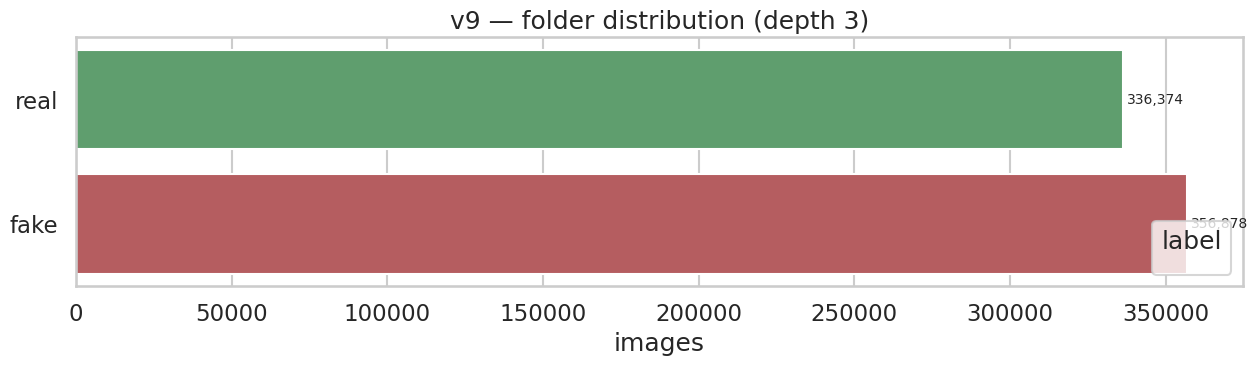

/tmp/ipykernel_3159095/2426793228.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="label", loc="lower right")


Saved : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/reports_v9_v11/v11-processing_folders.png


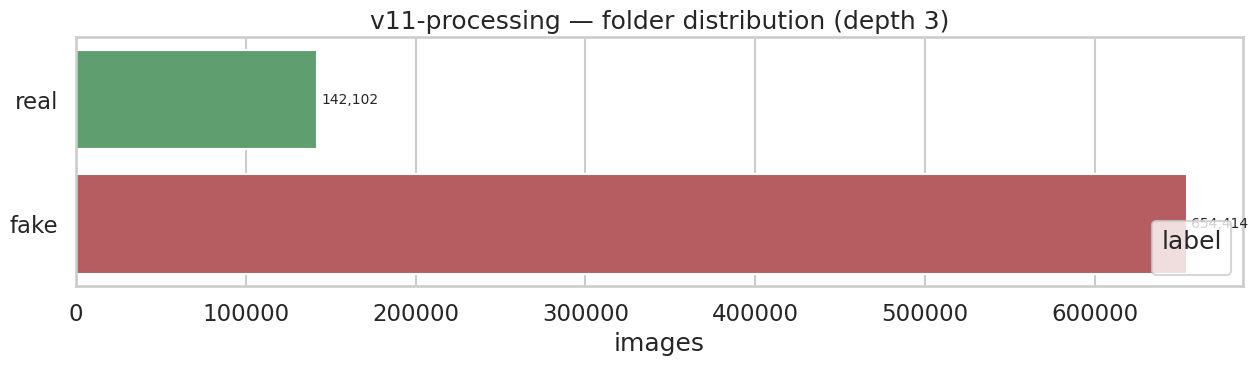

In [38]:
"""Per-dataset folder distribution at depth 3."""


def plot_folder_distribution(df: pd.DataFrame, root: Path, title: str, out_png: Path):
    folder_df = (
        df.assign(
            folder=df["filepath"].map(lambda p: depth_key(p, root)),
            label_name=df["label"].map(LABEL_NAME),
        )
        .groupby(["folder", "label_name"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
    )
    folder_df["short"] = folder_df["folder"].map(short_folder)
    folder_order = (
        folder_df.groupby("short")["count"].sum().sort_values(ascending=True).index.tolist()
    )

    height = max(4.0, 0.45 * len(folder_order) + 1.5)
    fig, ax = plt.subplots(figsize=(13, height))
    sns.barplot(
        data=folder_df, y="short", x="count", hue="label_name",
        palette=LABEL_PALETTE, order=folder_order, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("images")
    ax.set_ylabel("")
    ax.legend(title="label", loc="lower right")
    annotate_bars(ax)
    fig.tight_layout()
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    print(f"Saved : {out_png}")
    plt.show()


plot_folder_distribution(
    df_v9, V9_ROOT,
    "v9 — folder distribution (depth 3)",
    REPORT_DIR / "v9_folders.png",
)

plot_folder_distribution(
    df_v11, V11_ROOT,
    "v11-processing — folder distribution (depth 3)",
    REPORT_DIR / "v11-processing_folders.png",
)

Saved : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/reports_v9_v11/overlap_folders.png


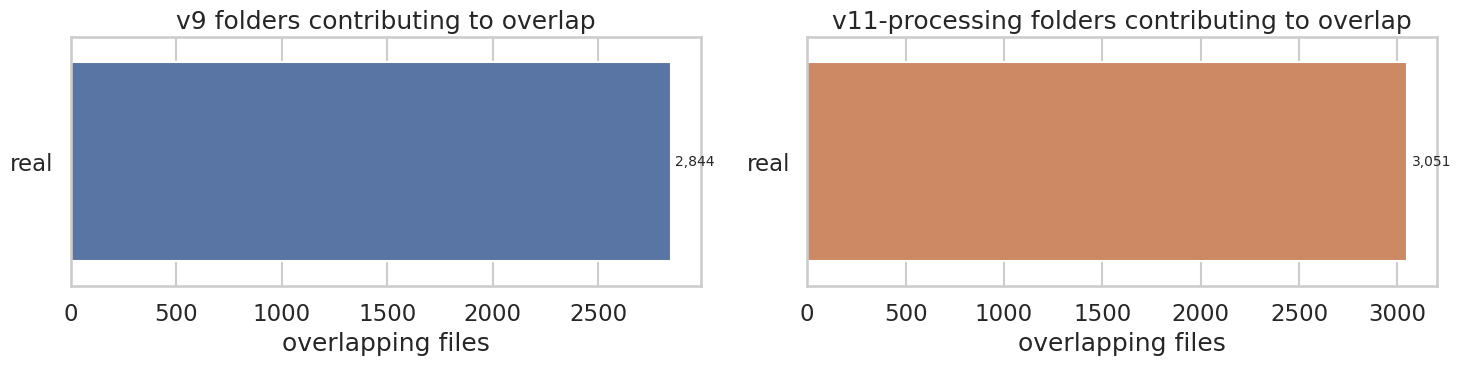


All visual reports written to: /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/reports_v9_v11


In [39]:
"""Overlap by folder — top contributors on each side."""

if overlap_keys.empty:
    print("No overlap to plot.")
else:
    folder_v9_overlap = (
        df_v9_keyed.merge(overlap_keys[key_cols], on=key_cols, how="inner")
                   .assign(folder=lambda x: x["filepath"].map(lambda p: depth_key(p, V9_ROOT)))
                   .groupby("folder", as_index=False)
                   .size()
                   .rename(columns={"size": "overlap_files"})
                   .sort_values("overlap_files", ascending=True)
    )
    folder_v11_overlap = (
        df_v11_keyed.merge(overlap_keys[key_cols], on=key_cols, how="inner")
                    .assign(folder=lambda x: x["filepath"].map(lambda p: depth_key(p, V11_ROOT)))
                    .groupby("folder", as_index=False)
                    .size()
                    .rename(columns={"size": "overlap_files"})
                    .sort_values("overlap_files", ascending=True)
    )

    n_panels = sum(not d.empty for d in (folder_v9_overlap, folder_v11_overlap)) or 1
    height = max(
        4.0,
        0.45 * max(len(folder_v9_overlap), len(folder_v11_overlap)) + 1.5,
    )
    fig, axes = plt.subplots(1, n_panels, figsize=(15, height), squeeze=False)

    panels = [
        ("v9 folders contributing to overlap", folder_v9_overlap, DS_PALETTE["v9"]),
        ("v11-processing folders contributing to overlap", folder_v11_overlap, DS_PALETTE["v11-processing"]),
    ]
    panels = [p for p in panels if not p[1].empty]

    for ax, (title, data, color) in zip(axes[0], panels):
        data = data.assign(short=data["folder"].map(short_folder))
        sns.barplot(
            data=data, y="short", x="overlap_files",
            color=color, ax=ax,
        )
        ax.set_title(title)
        ax.set_xlabel("overlapping files")
        ax.set_ylabel("")
        annotate_bars(ax)

    fig.tight_layout()
    overlap_png = REPORT_DIR / "overlap_folders.png"
    fig.savefig(overlap_png, dpi=150, bbox_inches="tight")
    print(f"Saved : {overlap_png}")
    plt.show()

    print()
    print(f"All visual reports written to: {REPORT_DIR}")